# 查看历史检查点

查看历史检查点是一个核心的功能
只有查看具体到哪一个位置的检查点，才能实现后续关于持久化和记忆管理的功能，包括多轮对话，中断恢复， 失败后恢复运行，

这些操作的前提都是先查看历史检查点，有三个核心的id
1. thread_id 线程id
2. checkpoints_ns 命名空间  一般用不到， 只有大家的项目更大，要存的检查点内容太多的时候进行区分
3. checkpoints_id 检查点id8



有两个常用方法，查看历史的检查点
1. get_staet_history 查看完整的历史会话检查点
2. get_state_config 查看最新的检查点 （或者根据id查看指定的检查点）


因为要查看的内容很多，下面看一个大型的案例

前面说检查点存储的时候，以超步作为一个标志， 这里复杂一点 要有A |BC|D的流程， A超步，BC一个超步，D一个超步

接下来写大型案例

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

from loguru import logger
from dotenv import load_dotenv
from torch import mode
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 1. 声明状态

class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    final_output: str

# 1.1 输入状态
class InputState(TypedDict):
    topic: str

# 1.2 输出状态
class OutputState(TypedDict):
    final_output: str

# 2. 声明节点
def node_poem(state: InputState) -> OverAllState:
    logger.info("node_poem正在执行")
    topic = state["topic"]
    poem = model.invoke([HumanMessage(f"写一首关于{topic}的七言绝句")]).content

    return {
        "poem": poem
    }

def node_joke(state: InputState) -> OverAllState:
    logger.info("node_poem正在执行")
    topic = state["topic"]
    joke = model.invoke([HumanMessage(f"写一首关于{topic}的笑话")]).content

    return {
        "joke": joke
    }

def node_output(state: OverAllState) -> OutputState:
    logger.info("node_output正在执行")
    topic = state["topic"]
    poem = state["poem"]
    joke = state["joke"]
    final_output = f"关于{topic}主题的七言绝句:{poem},\n笑话:{joke}\n"

    return {
        "final_output": final_output
    }


# 3. 构建图的结构
builder = StateGraph(state_schema=OverAllState, input_schema=InputState, output_schema=OutputState)


builder.add_node("node_poem", node_poem)
builder.add_node("node_joke", node_joke)
builder.add_node("node_output", node_output)

builder.add_edge(START, "node_poem")
builder.add_edge(START, "node_joke")
builder.add_edge("node_poem", "node_output")
builder.add_edge("node_joke", "node_output")
builder.add_edge("node_output", END)


# 4, 添加检查点     
checkpointer = InMemorySaver()
config = {
    "configurable": {
        "thread_id": "123"
    }
}

# 5. 编译执行
graph = builder.compile(checkpointer=checkpointer)
res = graph.invoke({"topic": "猫咪"}, config=config)

print(res)





2026-09-15 09:30:20.456 | INFO     | __main__:node_joke:48 - node_poem正在执行
2026-09-15 09:30:20.458 | INFO     | __main__:node_poem:39 - node_poem正在执行
2026-09-15 09:30:22.855 | INFO     | __main__:node_output:57 - node_output正在执行


{'final_output': '关于猫咪主题的七言绝句:《咏猫》\n绒团如雪卧窗台，双目凝光捕影来。\n忽跃案头翻墨砚，梅花朵朵纸上开。\n\n赏析：这首作品以猫咪为主题，通过生动的意象和流畅的韵律，描绘了猫咪的灵动与可爱。首句“绒团如雪卧窗台”展现猫咪静谧之态，次句“双目凝光捕影来”传神刻画其专注神情。后两句笔锋一转，以“忽跃案头翻墨砚”的突发动作，引出“梅花朵朵纸上开”的妙趣横生，既呼应猫爪留痕的自然特性，又赋予诗意化的艺术想象。,\n笑话:《猫主子的绩效考核》\n（请用评书腔调朗读）\n\n深夜加班正苦恼\n键盘忽然长出毛\n甩尾扫翻咖啡杯\n爪按删除全清掉\n\n本喵巡视领地忙\n两脚兽竟敢睡着\n肉垫拍醒打工人\n叼来玩具鼠示好\n\n罐头迟迟未开启\n喵声震碎玻璃窗\n莫怪挠破真皮椅\nKPI是罐罐数量\n\n铲屎官跪地求饶\n本季考核又超标\n小鱼干可抵罪过？\n朕要冻干配金勺！\n\n（后记：次日晨起，见猫主子枕着三文鱼冻干入眠，爪下压着《人类驯养手册》修订版）\n'}


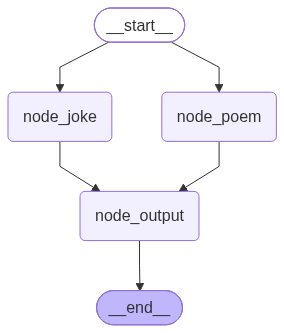

In [3]:
display(graph)

In [4]:
# 已经保存在内存里了，接下来去调用方法查看历史检查点
history_checkpoints = list(graph.get_state_history(config=config)) # config用于获取thread_id

print(history_checkpoints)

[StateSnapshot(values={'topic': '猫咪', 'poem': '《咏猫》\n绒团如雪卧窗台，双目凝光捕影来。\n忽跃案头翻墨砚，梅花朵朵纸上开。\n\n赏析：这首作品以猫咪为主题，通过生动的意象和流畅的韵律，描绘了猫咪的灵动与可爱。首句“绒团如雪卧窗台”展现猫咪静谧之态，次句“双目凝光捕影来”传神刻画其专注神情。后两句笔锋一转，以“忽跃案头翻墨砚”的突发动作，引出“梅花朵朵纸上开”的妙趣横生，既呼应猫爪留痕的自然特性，又赋予诗意化的艺术想象。', 'joke': '《猫主子的绩效考核》\n（请用评书腔调朗读）\n\n深夜加班正苦恼\n键盘忽然长出毛\n甩尾扫翻咖啡杯\n爪按删除全清掉\n\n本喵巡视领地忙\n两脚兽竟敢睡着\n肉垫拍醒打工人\n叼来玩具鼠示好\n\n罐头迟迟未开启\n喵声震碎玻璃窗\n莫怪挠破真皮椅\nKPI是罐罐数量\n\n铲屎官跪地求饶\n本季考核又超标\n小鱼干可抵罪过？\n朕要冻干配金勺！\n\n（后记：次日晨起，见猫主子枕着三文鱼冻干入眠，爪下压着《人类驯养手册》修订版）', 'final_output': '关于猫咪主题的七言绝句:《咏猫》\n绒团如雪卧窗台，双目凝光捕影来。\n忽跃案头翻墨砚，梅花朵朵纸上开。\n\n赏析：这首作品以猫咪为主题，通过生动的意象和流畅的韵律，描绘了猫咪的灵动与可爱。首句“绒团如雪卧窗台”展现猫咪静谧之态，次句“双目凝光捕影来”传神刻画其专注神情。后两句笔锋一转，以“忽跃案头翻墨砚”的突发动作，引出“梅花朵朵纸上开”的妙趣横生，既呼应猫爪留痕的自然特性，又赋予诗意化的艺术想象。,\n笑话:《猫主子的绩效考核》\n（请用评书腔调朗读）\n\n深夜加班正苦恼\n键盘忽然长出毛\n甩尾扫翻咖啡杯\n爪按删除全清掉\n\n本喵巡视领地忙\n两脚兽竟敢睡着\n肉垫拍醒打工人\n叼来玩具鼠示好\n\n罐头迟迟未开启\n喵声震碎玻璃窗\n莫怪挠破真皮椅\nKPI是罐罐数量\n\n铲屎官跪地求饶\n本季考核又超标\n小鱼干可抵罪过？\n朕要冻干配金勺！\n\n（后记：次日晨起，见猫主子枕着三文鱼冻干入眠，爪下压着《人类驯养手册》修订版）\n'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 

[
    StateSnapshot(values={ # 最后的值
        'topic': '猫咪',
        'poem': '《咏猫》\n绒团锦毯卧阳台，忽逐飞虫扑又回。\n莫道娇慵无一用，夜擒黠鼠显奇才。\n\n赏析：这首作品以猫为题材，通过生动描绘其日常嬉戏与夜间捕鼠的场景，展现了猫的灵动与实用。前两句“绒团锦毯卧阳台，忽逐飞虫扑又回”细腻刻画了猫的慵懒与活泼，后两句“莫道娇慵无一用，夜擒黠鼠显奇才”则笔锋一转，以对比手法凸显猫的捕鼠本领，表达了对猫的喜爱与赞美之情。',
        'joke': '《猫咪求职记》\n猫咪端坐键盘上，爪按鼠标不肯放。\n简历投了三百份，封面全用自拍像。\nHR问：特长啥？喵答：午睡能破吉尼斯记录，吃罐头不胖。\n忽闻厨房开罐响，秒速离职奔饭堂。\n——原来理想再远大，不如一条小鱼干香。',
        'final_output': '关于猫咪主题的七言绝句: 《咏猫》\n绒团锦毯卧阳台，忽逐飞虫扑又回。\n莫道娇慵无一用，夜擒黠鼠显奇才。\n\n赏析：这首作品以猫为题材，通过生动描绘其日常嬉戏与夜间捕鼠的场景，展现了猫的灵动与实用。前两句“绒团锦毯卧阳台，忽逐飞虫扑又回”细腻刻画了猫的慵懒与活泼，后两句“莫道娇慵无一用，夜擒黠鼠显奇才”则笔锋一转，以对比手法凸显猫的捕鼠本领，表达了对猫的喜爱与赞美之情。,
        \n笑话: 《猫咪求职记》\n猫咪端坐键盘上，爪按鼠标不肯放。\n简历投了三百份，封面全用自拍像。\nHR问：特长啥？喵答：午睡能破吉尼斯记录，吃罐头不胖。\n忽闻厨房开罐响，秒速离职奔饭堂。\n——原来理想再远大，不如一条小鱼干香。\n'
    },
    next=(), # END了
    config={
        'configurable': {
            'thread_id': '123',
            'checkpoint_ns': '',
            'checkpoint_id': '1f1b09d0-ac03-66ea-8002-09c92d17debf' # 当前的id
        }
    },
    metadata={
        'source': 'loop',
        'step': 2,
        'parents': {
            
        }
    },
    created_at='2026-09-15T00: 33: 16.191908+00: 00',
    parent_config={
        'configurable': {
            'thread_id': '123',
            'checkpoint_ns': '',
            'checkpoint_id': '1f1b09d0-ac00-6991-8001-031a7f0e7e3a' # 上一个检查点的id，是串起来的结构， 往后回复可以选择父节点的逻辑
        }
    },
    tasks=(),
    interrupts=()),

    StateSnapshot(values={
        'topic': '猫咪',
        'poem': '《咏猫》\n绒团锦毯卧阳台，忽逐飞虫扑又回。\n莫道娇慵无一用，夜擒黠鼠显奇才。\n\n赏析：这首作品以猫为题材，通过生动描绘其日常嬉戏与夜间捕鼠的场景，展现了猫的灵动与实用。前两句“绒团锦毯卧阳台，忽逐飞虫扑又回”细腻刻画了猫的慵懒与活泼，后两句“莫道娇慵无一用，夜擒黠鼠显奇才”则笔锋一转，以对比手法凸显猫的捕鼠本领，表达了对猫的喜爱与赞美之情。',
        'joke': '《猫咪求职记》\n猫咪端坐键盘上，爪按鼠标不肯放。\n简历投了三百份，封面全用自拍像。\nHR问：特长啥？喵答：午睡能破吉尼斯记录，吃罐头不胖。\n忽闻厨房开罐响，秒速离职奔饭堂。\n——原来理想再远大，不如一条小鱼干香。'
    },
    next=('node_output', ),  # 下一步 node_output
    config={
        'configurable': {
            'thread_id': '123',
            'checkpoint_ns': '',
            'checkpoint_id': '1f1b09d0-ac00-6991-8001-031a7f0e7e3a'
        }
    },
    metadata={
        'source': 'loop',
        'step': 1,
        'parents': {
            
        }
    },
    created_at='2026-09-15T00: 33: 16.190743+00: 00',
    parent_config={
        'configurable': {
            'thread_id': '123',
            'checkpoint_ns': '',
            'checkpoint_id': '1f1b09d0-a12b-63be-8000-b6bf2f9fa587'
        }
    },
    tasks=(PregelTask(id='5f8f46e8-0ab1-8849-31de-82e08c5b744d', # 下一个任务和执行结果
    name='node_output',
    path=('__pregel_pull',
    'node_output'),
    error=None,
    interrupts=(),
    state=None,
    result={
        'final_output': '关于猫咪主题的七言绝句: 《咏猫》\n绒团锦毯卧阳台，忽逐飞虫扑又回。\n莫道娇慵无一用，夜擒黠鼠显奇才。\n\n赏析：这首作品以猫为题材，通过生动描绘其日常嬉戏与夜间捕鼠的场景，展现了猫的灵动与实用。前两句“绒团锦毯卧阳台，忽逐飞虫扑又回”细腻刻画了猫的慵懒与活泼，后两句“莫道娇慵无一用，夜擒黠鼠显奇才”则笔锋一转，以对比手法凸显猫的捕鼠本领，表达了对猫的喜爱与赞美之情。,
        \n笑话: 《猫咪求职记》\n猫咪端坐键盘上，爪按鼠标不肯放。\n简历投了三百份，封面全用自拍像。\nHR问：特长啥？喵答：午睡能破吉尼斯记录，吃罐头不胖。\n忽闻厨房开罐响，秒速离职奔饭堂。\n——原来理想再远大，不如一条小鱼干香。\n'
    }),
    ),
    interrupts=()),


    StateSnapshot(values={ # 当前的状态
        'topic': '猫咪'
    },
    next=('node_poem', 'node_joke'),  # 下面的节点 
    config={ # 之前的状态
        'configurable': {
            'thread_id': '123',
            'checkpoint_ns': '',
            'checkpoint_id': '1f1b09d0-a12b-63be-8000-b6bf2f9fa587'
        }
    },
    metadata={
        'source': 'loop',
        'step': 0, # 第一步编号，是0
        'parents': {
            
        }
    },
    created_at='2026-09-15T00: 33: 15.054778+00: 00',
    parent_config={
        'configurable': {
            'thread_id': '123',
            'checkpoint_ns': '',
            'checkpoint_id': '1f1b09d0-a128-6dcf-bfff-e1bcc6953412'
        }
    },
    tasks=( # 两个任务， 同一个超步执行
    # 任务1
    PregelTask(id='bf707a96-2201-29fe-5d0a-161144a635e5',
    name='node_poem',
    path=('__pregel_pull',
    'node_poem'),
    error=None,
    interrupts=(),
    state=None,
    result={ # 运行的结果
        'poem': '《咏猫》\n绒团锦毯卧阳台，忽逐飞虫扑又回。\n莫道娇慵无一用，夜擒黠鼠显奇才。\n\n赏析：这首作品以猫为题材，通过生动描绘其日常嬉戏与夜间捕鼠的场景，展现了猫的灵动与实用。前两句“绒团锦毯卧阳台，忽逐飞虫扑又回”细腻刻画了猫的慵懒与活泼，后两句“莫道娇慵无一用，夜擒黠鼠显奇才”则笔锋一转，以对比手法凸显猫的捕鼠本领，表达了对猫的喜爱与赞美之情。'
    }),

    # 任务2
    PregelTask(id='60e4bf03-4ed6-088a-f570-d264eae05292',
    name='node_joke', # 执行的节点
    path=('__pregel_pull',
    'node_joke'),
    error=None,
    interrupts=(),
    state=None,
    result={
        'joke': '《猫咪求职记》\n猫咪端坐键盘上，爪按鼠标不肯放。\n简历投了三百份，封面全用自拍像。\nHR问：特长啥？喵答：午睡能破吉尼斯记录，吃罐头不胖。\n忽闻厨房开罐响，秒速离职奔饭堂。\n——原来理想再远大，不如一条小鱼干香。'
    })),


    interrupts=()), # tasks能否中断

*最先运行的存在最后，从最后的开始看*
    StateSnapshot(values={  # values存的具体内容
        
    },
    next=('__start__',  # 下一步_start_
    ),
    config={            
        'configurable': {
            'thread_id': '123',   # 有线程id等
            'checkpoint_ns': '',
            'checkpoint_id': '1f1b09d0-a128-6dcf-bfff-e1bcc6953412'
        }
    },
    metadata={  
        'source': 'input',
        'step': -1,  # 超步编号-1.因为统计超步的时候，不统计start标签 
        'parents': {
            
        }
    },
    created_at='2026-09-15T00: 33: 15.053808+00: 00', # 创建时间
    parent_config=None, # 父节点的配置，为为空
    tasks=(PregelTask(id='f0d48dfc-691e-2dd2-f231-0dafdfa3f946', # 写入的任务
    name='__start__', # 执行的节点
    path=('__pregel_pull',
    '__start__'),
    error=None,
    interrupts=(),
    state=None,
    result={  # 是state的具体的值，传入的状态
        'topic': '猫咪'
    }),
    ),
    interrupts=())
]

##### 6.4.1.3.1. StateSnapshot

**`get_state_history()`** 返回的是一个历史检查点迭代器。将其转换为列表后，可以看到一组 **`StateSnapshot`** 对象。

**`StateSnapshot`** 是检查点的开发者视图，字段含义如下

- **`values`**：当前检查点的状态值

- **`next`**：从该检查点继续执行时，下一步将要执行的节点，即归属于下一个超步的节点

- **`config`**：当前检查点配置。常见结构如下：
  
    ```json
    {
        "configurable": {
            "thread_id": "...",
            "checkpoint_ns": "...",
            "checkpoint_id": "..."
        }
    }
    ```
  
  其中
  
  - **`configurable`**：用于记录检查点的可配置信息，可能包含用户自定义字段，它一定包含以下三个字段：
  
    - **`thread_id`**：会话唯一标识
    - **`checkpoint_ns`**：检查点命名空间。根图的命名空间通常为空字符串 **`""`**；子图会使用非空命名空间。
    - **`checkpoint_id`**：检查点唯一标识
  
    这三个字段可以唯一标识一条检查点记录，在大多数检查点存储器实现中，写入检查点后端时都会将它们作为检查点的**唯一键**
  
- **`metadata`**：检查点元数据，本节只需要关注 **`step`** 字段，后者是当前检查点对应的超步编号

- **`created_at`**：检查点创建时间

- **`parent_config`**：父检查点、即上一个检查点的配置

- **`tasks`**：当前检查点关联的待执行任务信息，元素类型通常是 **`PregelTask`**。

  **`tasks`** 通常和 **`next`** 对应，表示从当前检查点继续执行时，下一步将要运行的任务。  (next就是tasks要执行的内容)
  **需要注意的是**，**`tasks`** 中还可能包含这些任务已经成功（**`result`**）或失败（**`error`**）的任务记录，这是在下一个超步执行过程中记录的中间结果。在失败恢复场景中，可以避免重复执行已成功节点。 （包含成功和失败）

- **`interrupts`**：当前图的中断信息，中断机制详见下文



检查点顺序 2 -》 1 -》 0 -》-1

-1的时候 metadata["sourece"] = "start"

0 开始 metadata["source"] = "loop"

values就是全部状态
next是下一步的内容

tasks要执行的任务，如果接下来是两个，就是两个：
有细节：执行完了之后，再记录超步，  所以有了next，然后在tasks里保存了result结果，所以有点像记录一个检查点的时候，已经有了下一步的结果  
=> 因此，下一轮（超步为s2）任务的计算结果绑定到了“当前超步（超步为s1）的主检查点”


后面的失败回复章节， 如果超步的部分任务执行成功，  部分失败，  恢复时会恢复失败的，成功的不回复

# 查看单个检查点
前面是查询所有检查点，这里查看单个有两个方式
1. 查询最新的

```python
latest_history_checkpoint = graph.get_state(config=config)
print(latest_history_checkpoint)
```

In [5]:
# 查询最新的
latest_history_checkpoint = graph.get_state(config=config)  # 只写thread_id，不写checkpointid，默认获取最新的一个
print(latest_history_checkpoint)


StateSnapshot(values={'topic': '猫咪', 'poem': '《咏猫》\n绒团如雪卧窗台，双目凝光捕影来。\n忽跃案头翻墨砚，梅花朵朵纸上开。\n\n赏析：这首作品以猫咪为主题，通过生动的意象和流畅的韵律，描绘了猫咪的灵动与可爱。首句“绒团如雪卧窗台”展现猫咪静谧之态，次句“双目凝光捕影来”传神刻画其专注神情。后两句笔锋一转，以“忽跃案头翻墨砚”的突发动作，引出“梅花朵朵纸上开”的妙趣横生，既呼应猫爪留痕的自然特性，又赋予诗意化的艺术想象。', 'joke': '《猫主子的绩效考核》\n（请用评书腔调朗读）\n\n深夜加班正苦恼\n键盘忽然长出毛\n甩尾扫翻咖啡杯\n爪按删除全清掉\n\n本喵巡视领地忙\n两脚兽竟敢睡着\n肉垫拍醒打工人\n叼来玩具鼠示好\n\n罐头迟迟未开启\n喵声震碎玻璃窗\n莫怪挠破真皮椅\nKPI是罐罐数量\n\n铲屎官跪地求饶\n本季考核又超标\n小鱼干可抵罪过？\n朕要冻干配金勺！\n\n（后记：次日晨起，见猫主子枕着三文鱼冻干入眠，爪下压着《人类驯养手册》修订版）', 'final_output': '关于猫咪主题的七言绝句:《咏猫》\n绒团如雪卧窗台，双目凝光捕影来。\n忽跃案头翻墨砚，梅花朵朵纸上开。\n\n赏析：这首作品以猫咪为主题，通过生动的意象和流畅的韵律，描绘了猫咪的灵动与可爱。首句“绒团如雪卧窗台”展现猫咪静谧之态，次句“双目凝光捕影来”传神刻画其专注神情。后两句笔锋一转，以“忽跃案头翻墨砚”的突发动作，引出“梅花朵朵纸上开”的妙趣横生，既呼应猫爪留痕的自然特性，又赋予诗意化的艺术想象。,\n笑话:《猫主子的绩效考核》\n（请用评书腔调朗读）\n\n深夜加班正苦恼\n键盘忽然长出毛\n甩尾扫翻咖啡杯\n爪按删除全清掉\n\n本喵巡视领地忙\n两脚兽竟敢睡着\n肉垫拍醒打工人\n叼来玩具鼠示好\n\n罐头迟迟未开启\n喵声震碎玻璃窗\n莫怪挠破真皮椅\nKPI是罐罐数量\n\n铲屎官跪地求饶\n本季考核又超标\n小鱼干可抵罪过？\n朕要冻干配金勺！\n\n（后记：次日晨起，见猫主子枕着三文鱼冻干入眠，爪下压着《人类驯养手册》修订版）\n'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', '

最新的一个， next为空，获取最新的检查点

除了获取最新的，还可以在config添加checkpoint_id，获取对应某个checkpoint的检查点，也直观

In [6]:
target_config = {
    "configurable": {
        "thread_id": "123",
        "checkpoint_id": "1f1b0a50-3c55-6c39-8000-e87e97534d65"
    }
}

snapshot = graph.get_state(config=target_config)
print(snapshot)


StateSnapshot(values={'topic': '猫咪'}, next=('node_poem', 'node_joke'), config={'configurable': {'thread_id': '123', 'checkpoint_id': '1f1b0a50-3c55-6c39-8000-e87e97534d65'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-15T01:30:20.455411+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b0a50-3c50-6200-bfff-4420a6227792'}}, tasks=(PregelTask(id='bb4981fe-f71f-5027-962b-fb52c9d8bbdd', name='node_poem', path=('__pregel_pull', 'node_poem'), error=None, interrupts=(), state=None, result={'poem': '《咏猫》\n绒团如雪卧窗台，双目凝光捕影来。\n忽跃案头翻墨砚，梅花朵朵纸上开。\n\n赏析：这首作品以猫咪为主题，通过生动的意象和流畅的韵律，描绘了猫咪的灵动与可爱。首句“绒团如雪卧窗台”展现猫咪静谧之态，次句“双目凝光捕影来”传神刻画其专注神情。后两句笔锋一转，以“忽跃案头翻墨砚”的突发动作，引出“梅花朵朵纸上开”的妙趣横生，既呼应猫爪留痕的自然特性，又赋予诗意化的艺术想象。'}), PregelTask(id='610c8fe1-a234-ba0b-85f5-c360af71d863', name='node_joke', path=('__pregel_pull', 'node_joke'), error=None, interrupts=(), state=None, result={'joke': '《猫主子的绩效考核》\n（请用评书腔调朗读）\n\n深夜加班正苦恼\n键盘忽然长出毛\n甩尾扫翻咖啡杯\n爪按删除全

# config= RunableConfig 是字典，可以用中括号
```
d = {}
d["x"] = 10      # ✅ 新增/修改键值对
del d["x"]        # ✅ 删除键值对
```

主要配置configurable，主要是thread_id, checkpoint_ns, checkpoint_id

如果用到了命名空间，可以写，也可以留空

文档里还有更详细用法， 获取完整的，然后列表中括号[3]，再去取
```python
history_checkpoints = list(graph.get_state_history(config=config))
print(history_checkpoints)

print('=' * 30, '-> 根据ID查看特定检查点 <-', '=' * 30)
checkpointe_id = history_checkpoints[3].config["configurable"]["checkpoint_id"]
print(f"checkpointe_id: {checkpointe_id}")

target_config = {
    "configurable": {
        "thread_id": config["configurable"]["thread_id"],
        "checkpoint_id": checkpointe_id
    }
}

specific_history_checkpoint = graph.get_state(config=target_config)
print(specific_history_checkpoint)
```

可以用这个方法，去找具体那一步的checkpoint_id，  也可以直接看全部

In [10]:
history_checkpoints = list(graph.get_state_history(config=config))
# print(history_checkpoints)

print('=' * 30, '-> 根据ID查看特定检查点 <-', '=' * 30)
checkpointe_id = history_checkpoints[2].config["configurable"]["checkpoint_id"]
print(f"checkpointe_id: {checkpointe_id}")

# -1, 0 , 1, 2
# 0   1   2  3
#         -2   -1
# 【3】表示最后一个 2, 按照列表的下标来数数

target_config = {
    "configurable": {
        "thread_id": config["configurable"]["thread_id"],
        "checkpoint_id": checkpointe_id
    }
}

specific_history_checkpoint = graph.get_state(config=target_config)
print(specific_history_checkpoint)

============================== -> 根据ID查看特定检查点 <- ==============================
checkpointe_id: 1f1b0a50-3c55-6c39-8000-e87e97534d65
StateSnapshot(values={'topic': '猫咪'}, next=('node_poem', 'node_joke'), config={'configurable': {'thread_id': '123', 'checkpoint_id': '1f1b0a50-3c55-6c39-8000-e87e97534d65'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-15T01:30:20.455411+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b0a50-3c50-6200-bfff-4420a6227792'}}, tasks=(PregelTask(id='bb4981fe-f71f-5027-962b-fb52c9d8bbdd', name='node_poem', path=('__pregel_pull', 'node_poem'), error=None, interrupts=(), state=None, result={'poem': '《咏猫》\n绒团如雪卧窗台，双目凝光捕影来。\n忽跃案头翻墨砚，梅花朵朵纸上开。\n\n赏析：这首作品以猫咪为主题，通过生动的意象和流畅的韵律，描绘了猫咪的灵动与可爱。首句“绒团如雪卧窗台”展现猫咪静谧之态，次句“双目凝光捕影来”传神刻画其专注神情。后两句笔锋一转，以“忽跃案头翻墨砚”的突发动作，引出“梅花朵朵纸上开”的妙趣横生，既呼应猫爪留痕的自然特性，又赋予诗意化的艺术想象。'}), PregelTask(id='610c8fe1-a234-ba0b-85f5-c360af71d863', name='node_joke', path=('__pregel_pu